# EDA PM10 — Calidad del aire Madrid (2018–2026)

Análisis exploratorio y limpieza de **PM10** sobre todas las estaciones que lo miden.


## Paso 0 — Setup y carga

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Permitir importar el pipeline del repo (src/etl/...)
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
from src.etl.limpiar_datos import limpiar_datos_live, DICCIONARIO_MAGNITUDES

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", 60)


RUTA_CSV = REPO_ROOT.parent / "datos_completos_2018_2026.csv"
RUTA_ESTACIONES = REPO_ROOT / "data" / "raw" / "estaciones-de-control.csv"
RUTA_PROCESSED = REPO_ROOT / "data" / "processed"

COD_PM10 = 10
print("CSV:", RUTA_CSV, "existe:", RUTA_CSV.exists())
print("Estaciones:", RUTA_ESTACIONES, "existe:", RUTA_ESTACIONES.exists())

CSV: /mnt/c/users/cfernandez/documents/pontia/asistentecontaminacion/datos_completos_2018_2026.csv existe: True
Estaciones: /mnt/c/users/cfernandez/documents/pontia/asistentecontaminacion/Asistente-Contaminacion-Madrid/data/raw/estaciones-de-control.csv existe: True


In [2]:

df_raw = pd.read_csv(RUTA_CSV, sep=";")
print("Filas totales (todas las magnitudes):", len(df_raw))

# 2025-2026 vienen DUPLICADOS
# 2ª copia queda idéntica -> deduplicamos por clave estación-día-magnitud.
clave_dup = ["PROVINCIA", "MUNICIPIO", "ESTACION", "MAGNITUD", "PUNTO_MUESTREO", "ANO", "MES", "DIA"]
n_antes = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=clave_dup, keep="last")
print("Filas duplicadas eliminadas:", n_antes - len(df_raw))
print("Filas tras dedup:", len(df_raw))

df_pm10_raw = df_raw[df_raw["MAGNITUD"] == COD_PM10].copy()
print("Filas PM10 (día-estación):", len(df_pm10_raw))

# Reutilizamos el pipeline del repo:
df = limpiar_datos_live(df_pm10_raw, str(RUTA_ESTACIONES))
df = df[df["contaminante"] == "PM10"].copy()
df["fecha"] = pd.to_datetime(df["fecha"])
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
print("Filas PM10 horarias (formato largo):", len(df))
df.head()

Filas totales (todas las magnitudes): 461465
Filas duplicadas eliminadas: 51522
Filas tras dedup: 409943
Filas PM10 (día-estación): 38653
Filas PM10 horarias (formato largo): 927672


,provincia,municipio,estacion,magnitud,contaminante,punto_muestreo,nombre_estacion,ano,mes,dia,hora,valor,validacion,fecha,dia_semana,es_fin_semana
62,28,79,24,10,PM10,28079024_10_47,Casa de Campo,2018,1,1,0,10.0,V,2018-01-01 00:00:00,0,False
38715,28,79,24,10,PM10,28079024_10_47,Casa de Campo,2018,1,1,1,18.0,V,2018-01-01 01:00:00,0,False
77368,28,79,24,10,PM10,28079024_10_47,Casa de Campo,2018,1,1,2,15.0,V,2018-01-01 02:00:00,0,False
116021,28,79,24,10,PM10,28079024_10_47,Casa de Campo,2018,1,1,3,11.0,V,2018-01-01 03:00:00,0,False
154674,28,79,24,10,PM10,28079024_10_47,Casa de Campo,2018,1,1,4,9.0,V,2018-01-01 04:00:00,0,False


In [3]:
# Panorama general
print("Rango temporal:", df["fecha"].min(), "->", df["fecha"].max())
print("Nº estaciones con PM10:", df["nombre_estacion"].nunique())
print("\nReparto de la marca de validación:")
print(df["validacion"].value_counts(dropna=False))
print("\n'valor' (µg/m3):")
df["valor"].describe()

Rango temporal: 2018-01-01 00:00:00 -> 2026-02-28 23:00:00
Nº estaciones con PM10: 15

Reparto de la marca de validación:
validacion
V    901765
N     25904
M         3
Name: count, dtype: int64

'valor' (µg/m3):


count    927672.000000
mean         18.632898
std          96.443944
min         -42.000000
25%           8.000000
50%          14.000000
75%          24.000000
max       89337.000000
Name: valor, dtype: float64

## Paso 1 — EDA

### 1.1 Cobertura por estación
No todas las estaciones miden PM10 ni durante todo el periodo.

In [4]:
cobertura = (
    df.groupby("nombre_estacion")
    .agg(
        inicio=("fecha", "min"),
        fin=("fecha", "max"),
        n_horas=("valor", "size"),
        n_validas=("valor", "count"),
        pct_invalido=("validacion", lambda s: (s != "V").mean() * 100),
        media=("valor", "mean"),
    )
    .sort_values("n_validas", ascending=False)
    .round(2)
)
cobertura

,inicio,fin,n_horas,n_validas,pct_invalido,media
nombre_estacion,,,,,,
Tres Olivos,2018-01-01,2026-02-28 23:00:00,71544,71544,1.35,17.69
Plaza Castilla,2018-01-01,2026-02-28 23:00:00,71424,71424,2.17,18.57
Farolillo,2018-01-01,2026-02-28 23:00:00,71400,71400,5.90,19.95
Sanchinarro,2018-01-01,2026-02-28 23:00:00,71328,71328,1.86,15.59
Cuatro Caminos,2018-01-01,2026-02-28 23:00:00,71184,71184,3.48,18.87
Casa de Campo,2018-01-01,2026-02-28 23:00:00,71160,71160,2.08,15.84
Vallecas,2018-01-01,2026-02-28 23:00:00,71112,71112,1.63,19.09
Méndez Álvaro,2018-01-01,2026-02-28 23:00:00,71088,71088,3.06,17.01
Castellana,2018-01-01,2026-02-28 23:00:00,71064,71064,2.30,17.82


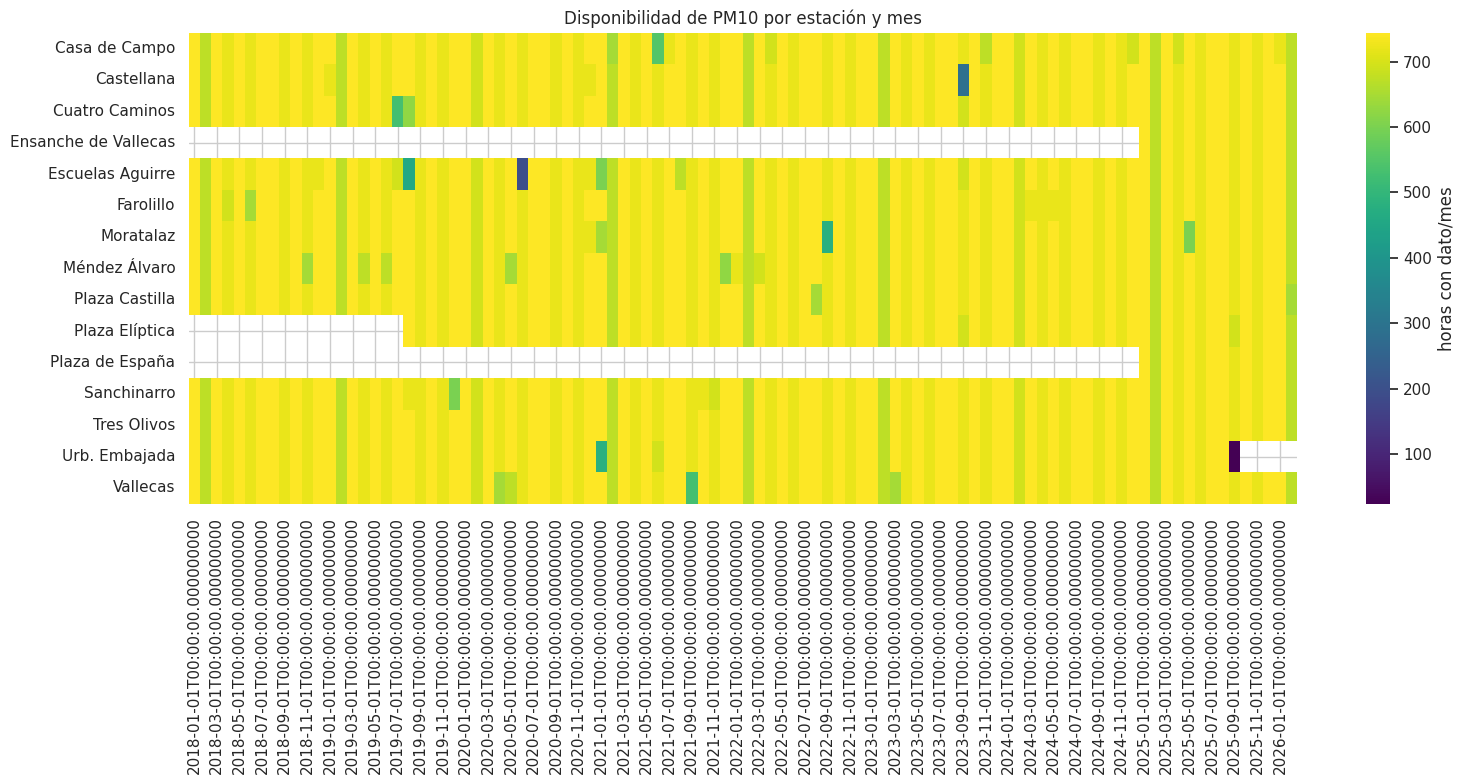

In [5]:
# Mapa de disponibilidad: estación x mes (nº de horas con dato)
disp = (
    df.assign(mes=df["fecha"].dt.to_period("M").dt.to_timestamp())
    .pivot_table(index="nombre_estacion", columns="mes", values="valor", aggfunc="count")
)
plt.figure(figsize=(16, 8))
sns.heatmap(disp, cmap="viridis", cbar_kws={"label": "horas con dato/mes"})
plt.title("Disponibilidad de PM10 por estación y mes")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.show()

### 1.2 Serie temporal
Media diaria agregada de todas las estaciones para ver tendencia

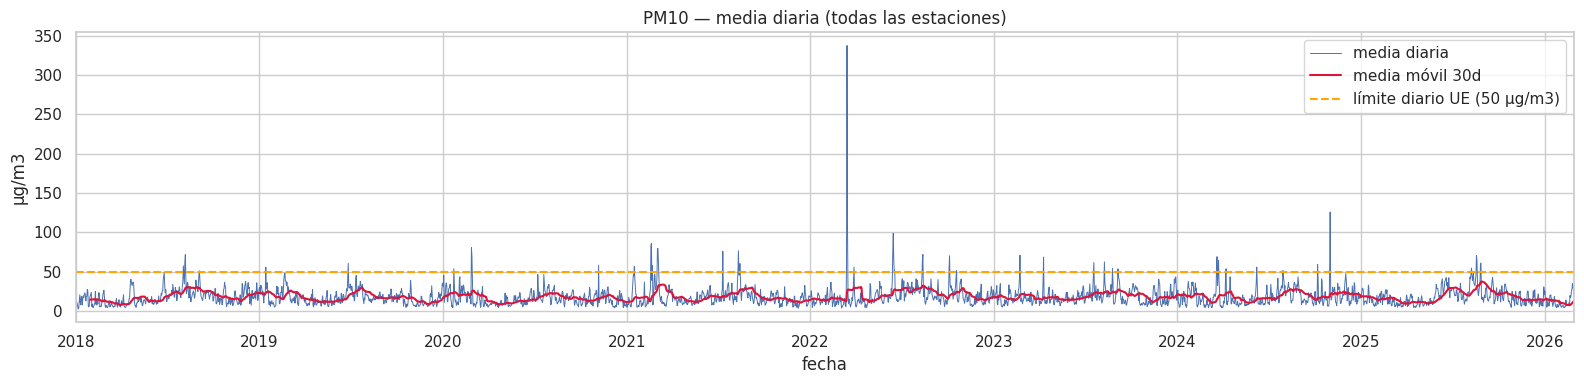

In [6]:
serie_diaria = (
    df[df["validacion"] == "V"]
    .set_index("fecha")["valor"]
    .resample("D")
    .mean()
)
plt.figure(figsize=(16, 4))
serie_diaria.plot(lw=0.7, label="media diaria")
serie_diaria.rolling(30).mean().plot(color="crimson", lw=1.5, label="media móvil 30d")
plt.axhline(50, color="orange", ls="--", label="límite diario UE (50 µg/m3)")
plt.title("PM10 — media diaria (todas las estaciones)")
plt.ylabel("µg/m3"); plt.legend(); plt.tight_layout(); plt.show()

In [7]:
##Analisis del outlier de 2022
print(serie_diaria.sort_values(ascending=False).head(10))

fecha
2022-03-15    337.516026
2024-10-31    125.987179
2022-03-16    109.298013
2022-06-15     98.983389
2021-02-19     85.983923
2021-02-18     82.935275
2020-02-27     80.697068
2021-03-03     79.508418
2021-03-04     79.441860
2021-08-11     76.782895
Name: valor, dtype: float64


In [8]:
dia = serie_diaria.idxmax()          # día de la media diaria máxima
print("Día con la media más alta:", dia, "->", round(serie_diaria.max(), 1), "µg/m3")

Día con la media más alta: 2022-03-15 00:00:00 -> 337.5 µg/m3


In [9]:
detalle = df[(df["fecha"].dt.date == dia.date())].sort_values("valor", ascending=False)
print(detalle[["nombre_estacion", "fecha", "valor", "validacion"]].head(15))

       nombre_estacion               fecha  valor validacion
251137        Vallecas 2022-03-15 06:00:00  721.0          V
212484        Vallecas 2022-03-15 05:00:00  708.0          V
212513   Méndez Álvaro 2022-03-15 05:00:00  682.0          V
212606   Urb. Embajada 2022-03-15 05:00:00  680.0          V
251075       Moratalaz 2022-03-15 06:00:00  678.0          V
289790        Vallecas 2022-03-15 07:00:00  677.0          V
251166   Méndez Álvaro 2022-03-15 06:00:00  674.0          V
212422       Moratalaz 2022-03-15 05:00:00  663.0          V
251259   Urb. Embajada 2022-03-15 06:00:00  658.0          V
251044   Casa de Campo 2022-03-15 06:00:00  650.0          V
289819   Méndez Álvaro 2022-03-15 07:00:00  636.0          V
289728       Moratalaz 2022-03-15 07:00:00  633.0          V
173831        Vallecas 2022-03-15 04:00:00  631.0          V
212391   Casa de Campo 2022-03-15 05:00:00  627.0          V
289912   Urb. Embajada 2022-03-15 07:00:00  623.0          V


In [10]:
piv = (df[df["fecha"].dt.date == dia.date()]
       .pivot_table(index="nombre_estacion", values="valor", aggfunc="max")
       .sort_values("valor", ascending=False))
print(piv)

                  valor
nombre_estacion        
Vallecas          721.0
Méndez Álvaro     682.0
Urb. Embajada     680.0
Moratalaz         678.0
Casa de Campo     650.0
Plaza Castilla    617.0
Sanchinarro       492.0
Tres Olivos       397.0
Cuatro Caminos    379.0
Castellana        352.0
Farolillo         337.0
Escuelas Aguirre  322.0
Plaza Elíptica    223.0


### 1.3 Estacionalidad
PM10 tiene ciclo diario (tráfico) y estacional.

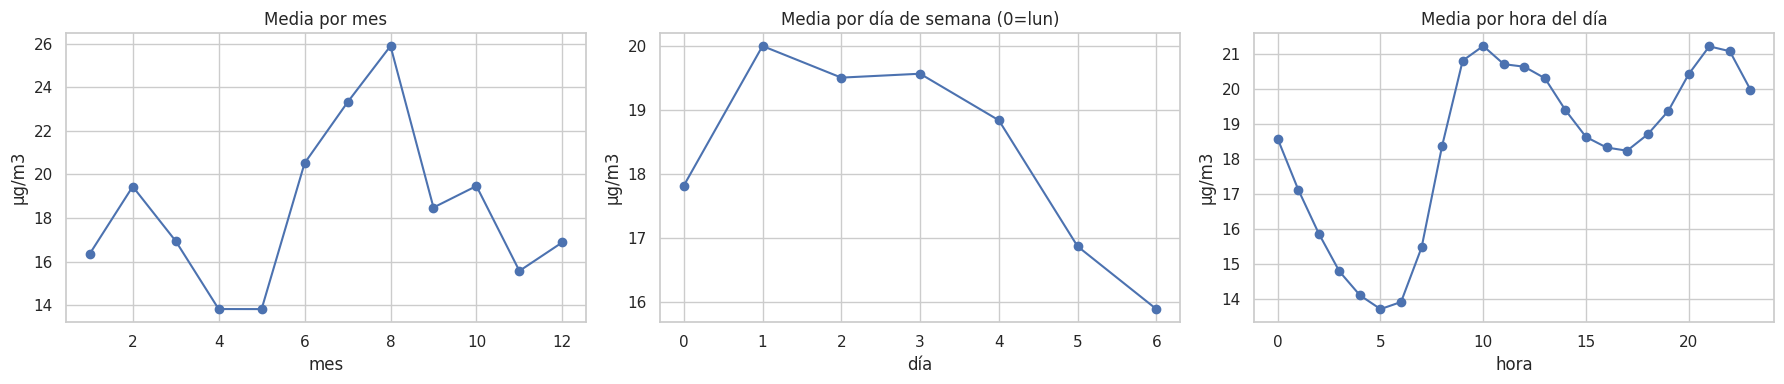

In [11]:
dfv = df[df["validacion"] == "V"].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
dfv.groupby(dfv["fecha"].dt.month)["valor"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Media por mes"); axes[0].set_xlabel("mes")
dfv.groupby("dia_semana")["valor"].mean().plot(ax=axes[1], marker="o")
axes[1].set_title("Media por día de semana (0=lun)"); axes[1].set_xlabel("día")
dfv.groupby("hora")["valor"].mean().plot(ax=axes[2], marker="o")
axes[2].set_title("Media por hora del día"); axes[2].set_xlabel("hora")
for ax in axes: ax.set_ylabel("µg/m3")
plt.tight_layout(); plt.show()

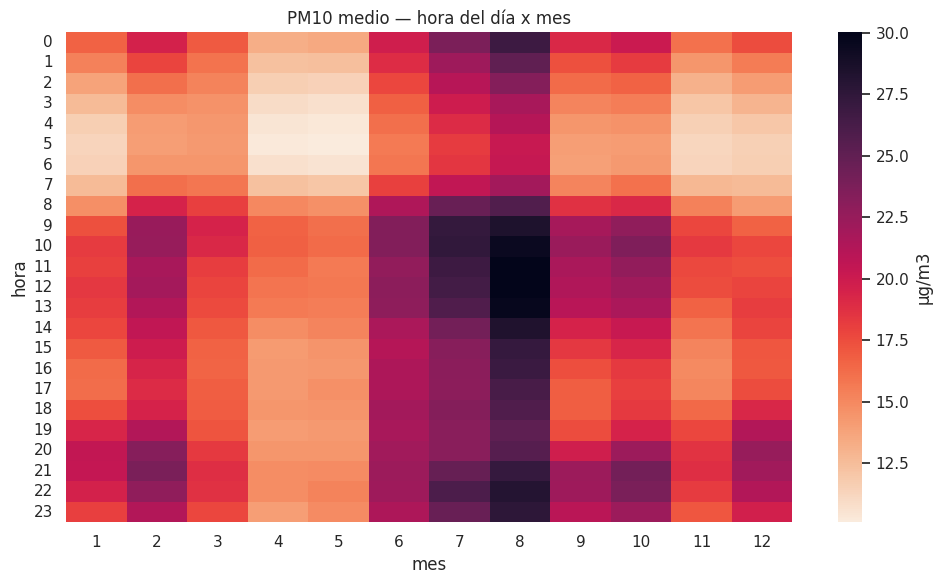

In [12]:
# Heatmap hora x mes: muestra cómo cambia el ciclo diario a lo largo del año
pivot = dfv.pivot_table(index="hora", columns=dfv["fecha"].dt.month, values="valor", aggfunc="mean")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap="rocket_r", cbar_kws={"label": "µg/m3"})
plt.title("PM10 medio — hora del día x mes")
plt.xlabel("mes"); plt.ylabel("hora"); plt.tight_layout(); plt.show()

### 1.4 Distribución
PM10 tiene cola derecha larga (episodios)

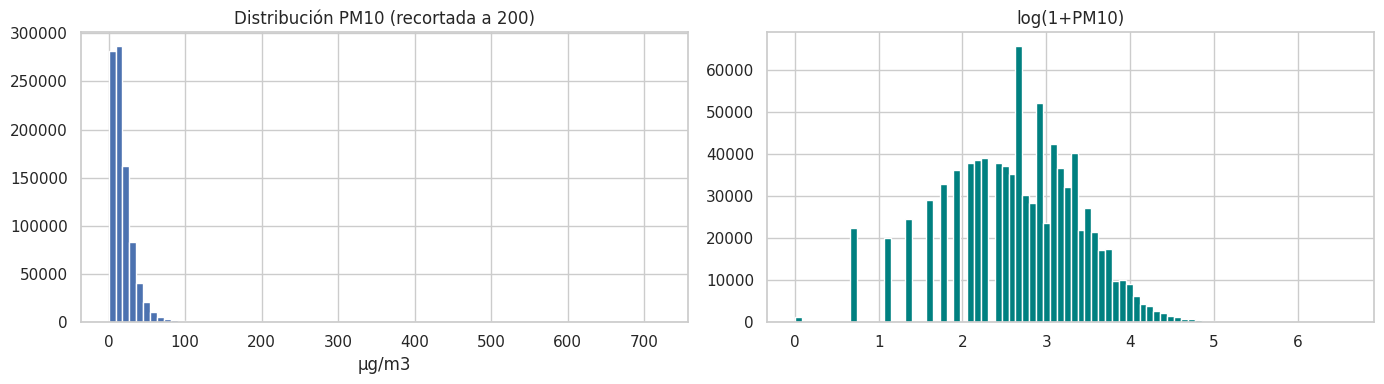

Percentiles:
0.500     14.0
0.900     36.0
0.950     46.0
0.990     76.0
0.999    157.0
Name: valor, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dfv["valor"].clip(upper=100000).hist(bins=80, ax=axes[0])
axes[0].set_title("Distribución PM10 (recortada a 200)"); axes[0].set_xlabel("µg/m3")
np.log1p(dfv["valor"].clip(lower=0)).hist(bins=80, ax=axes[1], color="teal")
axes[1].set_title("log(1+PM10)")
plt.tight_layout(); plt.show()
print("Percentiles:")
print(dfv["valor"].quantile([0.5, 0.9, 0.95, 0.99, 0.999]).round(1))

### 1.5 Análisis de la validación V/N (clave para anomalías)
El flag `validacion` distingue dato válido (`V`) de no válido (`N`/otros). Es la una etiqueta del dataset para separar errores de sensor de episodios reales: comparamos la distribución de los valores marcados inválidos frente a los válidos.

Datos por marca de validación:


,count,mean,std,min,25%,50%,75%,max
validacion,,,,,,,,
M,3.0,148.00,74.22,88.0,106.5,125.0,178.0,231.0
N,25904.0,28.47,568.23,-42.0,0.0,1.0,29.0,89337.0
V,901765.0,18.35,17.05,0.0,8.0,14.0,24.0,721.0


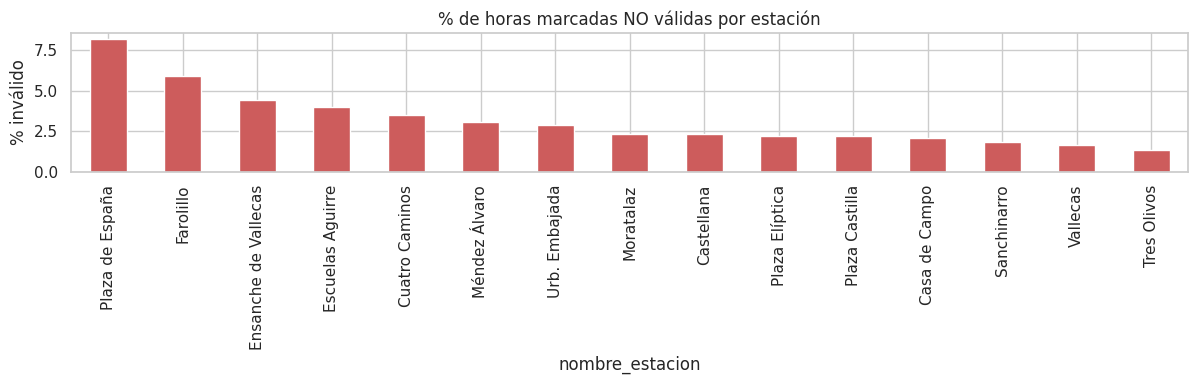

In [14]:
print("Datos por marca de validación:")
display(df.groupby("validacion")["valor"].describe().round(2))

# % de invalidación por estación (sensores problemáticos)
inval_est = (
    df.groupby("nombre_estacion")["validacion"]
    .apply(lambda s: (s != "V").mean() * 100)
    .sort_values(ascending=False)
)
plt.figure(figsize=(12, 4))
inval_est.plot(kind="bar", color="indianred")
plt.title("% de horas marcadas NO válidas por estación"); plt.ylabel("% inválido")
plt.tight_layout(); plt.show()

## Paso 2 — Limpieza

**Decisión de diseño:** mantenemos ambas vistas. Para *forecasting* usaremos solo válidos/imputados; para *detección de errores de sensor* conservamos el flag `validacion` como etiqueta. Por eso NO borramos los inválidos: los marcamos.

Pasos: (a) rejilla horaria continua por estación, (b) outliers físicamente imposibles, (c) imputación de huecos cortos.

In [15]:
# (a) Rejilla horaria continua por estación: explicita los huecos como NaN.
def rejilla_horaria(grupo):
    g = grupo.set_index("fecha").sort_index()
    idx = pd.date_range(g.index.min(), g.index.max(), freq="h")
    g = g.reindex(idx)
    g.index.name = "fecha"
    return g

cols_keep = ["fecha", "valor", "validacion"]
df_grid = (
    df[["nombre_estacion"] + cols_keep]
    .groupby("nombre_estacion", group_keys=True)
    .apply(lambda g: rejilla_horaria(g[cols_keep]))
    .reset_index()
)
print("Filas tras rejilla continua:", len(df_grid))
print("Huecos (NaN en valor):", df_grid["valor"].isna().sum(),
      f"({df_grid['valor'].isna().mean()*100:.1f}%)")

Filas tras rejilla continua: 932256
Huecos (NaN en valor): 4584 (0.5%)


/tmp/ipykernel_34015/1146909461.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: rejilla_horaria(g[cols_keep]))


In [ ]:
# (b) Outliers imposibles y flags de calidad.
#  - PM10 negativo = error de sensor
#  - marcamos > 1000 µg/m3 como sospechoso
df_grid["flag_negativo"] = df_grid["valor"] < 0
df_grid["flag_extremo"] = df_grid["valor"] > 1000
df_grid["flag_invalido_origen"] = df_grid["validacion"].notna() & (df_grid["validacion"] != "V")
df_grid["flag_hueco"] = df_grid["valor"].isna()

print(df_grid[["flag_negativo", "flag_extremo", "flag_invalido_origen", "flag_hueco"]].sum())

# 'valor_limpio': base para forecasting. Negativos/extremos -> NaN (se imputarán o quedarán como hueco).
df_grid["valor_limpio"] = df_grid["valor"].where(
    ~(df_grid["flag_negativo"] | df_grid["flag_extremo"]), np.nan
)

flag_negativo              59
flag_extremo               27
flag_invalido_origen    25907
flag_hueco               4584
dtype: int64


In [17]:
# (c) Imputación SOLO de huecos cortos (<=3h) por interpolación temporal, por estación.
#     Huecos largos se dejan como NaN (no inventamos datos para episodios largos sin sensor).
def imputar_cortos(s, max_gap=3):
    return s.interpolate(method="time", limit=max_gap, limit_area="inside")

df_grid = df_grid.sort_values(["nombre_estacion", "fecha"])
df_grid["valor_imputado"] = (
    df_grid.set_index("fecha")
    .groupby("nombre_estacion")["valor_limpio"]
    .transform(imputar_cortos)
    .values
)
df_grid["fue_imputado"] = df_grid["valor_limpio"].isna() & df_grid["valor_imputado"].notna()
print("Valores imputados (huecos <=3h):", df_grid["fue_imputado"].sum())
print("Huecos restantes tras imputar:", df_grid["valor_imputado"].isna().sum())

Valores imputados (huecos <=3h): 227
Huecos restantes tras imputar: 4443


In [18]:
# Features de calendario sobre la rejilla continua (para los notebooks de modelado).
df_grid["hora"] = df_grid["fecha"].dt.hour
df_grid["dia_semana"] = df_grid["fecha"].dt.dayofweek
df_grid["mes"] = df_grid["fecha"].dt.month
df_grid["es_fin_semana"] = df_grid["dia_semana"].isin([5, 6])
df_grid.head()

,nombre_estacion,fecha,valor,validacion,flag_negativo,flag_extremo,flag_invalido_origen,flag_hueco,valor_limpio,valor_imputado,fue_imputado,hora,dia_semana,mes,es_fin_semana
0,Casa de Campo,2018-01-01 00:00:00,10.0,V,False,False,False,False,10.0,10.0,False,0,0,1,False
1,Casa de Campo,2018-01-01 01:00:00,18.0,V,False,False,False,False,18.0,18.0,False,1,0,1,False
2,Casa de Campo,2018-01-01 02:00:00,15.0,V,False,False,False,False,15.0,15.0,False,2,0,1,False
3,Casa de Campo,2018-01-01 03:00:00,11.0,V,False,False,False,False,11.0,11.0,False,3,0,1,False
4,Casa de Campo,2018-01-01 04:00:00,9.0,V,False,False,False,False,9.0,9.0,False,4,0,1,False


In [19]:
# Guardar también en CSV (sin dependencias extra; útil para inspección rápida y portabilidad).
RUTA_PROCESSED.mkdir(parents=True, exist_ok=True)
salida_csv = RUTA_PROCESSED / "pm10_horario_limpio.csv"
df_grid.to_csv(salida_csv, index=False)
print("Guardado:", salida_csv, "|", len(df_grid), "filas")

Guardado: /mnt/c/users/cfernandez/documents/pontia/asistentecontaminacion/Asistente-Contaminacion-Madrid/data/processed/pm10_horario_limpio.csv | 932256 filas


Pendiente (notebooks aparte):
- Feature engineering: lags (1h, 24h, 168h), medias móviles, festivos Madrid, covariables (NO2/O3, idealmente meteo: viento/lluvia).
- Anomalías
- Forecasting: baseline estacional 
